# 01 — Data Exploration

Explore the PrimeVul v0.1 dataset, verify embeddings, and visualize the representation space.

**No training in this notebook.** Just data loading, stats, and figures.

In [1]:
import json
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Project root
ROOT = Path("..").resolve()
DATA_RAW = ROOT / "data" / "raw" / "PrimeVul_v0.1"
EMB_CB = ROOT / "data" / "processed" / "embeddings"
EMB_VB = ROOT / "data" / "processed" / "embeddings_vulberta"

sys.path.insert(0, str(ROOT / "src"))

# Dark theme for all plots
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#161b22",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#e6edf3",
    "text.color": "#e6edf3",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "grid.color": "#30363d",
    "grid.alpha": 0.5,
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "legend.labelcolor": "#e6edf3",
    "font.size": 12,
    "figure.dpi": 150,
})

## 1. Raw dataset stats

Load the PrimeVul v0.1 JSONL files and compute basic statistics.

In [2]:
def load_jsonl(path):
    records = []
    with open(path) as f:
        for line in f:
            records.append(json.loads(line.strip()))
    return records

splits = {}
for name, fname in [("train", "primevul_train.jsonl"), 
                     ("valid", "primevul_valid.jsonl"),
                     ("test", "primevul_test.jsonl"),
                     ("test_paired", "primevul_test_paired.jsonl")]:
    path = DATA_RAW / fname
    if path.exists():
        records = load_jsonl(path)
        n_vuln = sum(1 for r in records if r["target"] == 1)
        splits[name] = {"records": records, "total": len(records), "vuln": n_vuln}
        print(f"{name:15s}: {len(records):>8,} total, {n_vuln:>6,} vulnerable ({n_vuln/len(records):.2%})")

print(f"\nClass prior (train): {splits['train']['vuln'] / splits['train']['total']:.4f}")

train          :  175,797 total,  4,862 vulnerable (2.77%)
valid          :   23,948 total,    593 vulnerable (2.48%)


test           :   24,788 total,    549 vulnerable (2.21%)
test_paired    :      870 total,    435 vulnerable (50.00%)

Class prior (train): 0.0277


## 2. Sample record

What does one PrimeVul record look like?

In [3]:
# Show a vulnerable sample (truncate func for readability)
sample = splits["train"]["records"][0]
display_sample = {k: (v[:200] + "..." if isinstance(v, str) and len(v) > 200 else v) 
                  for k, v in sample.items()}
print(json.dumps(display_sample, indent=2))

{
  "idx": 0,
  "project": "openssl",
  "commit_id": "ca989269a2876bae79393bd54c3e72d49975fc75",
  "project_url": "https://github.com/openssl/openssl",
  "commit_url": "https://git.openssl.org/gitweb/?p=openssl.git;a=commit;h=ca989269a2876bae79393bd54c3e72d49975fc75",
  "commit_message": "Use version in SSL_METHOD not SSL structure.\n\nWhen deciding whether to use TLS 1.2 PRF and record hash algorithms\nuse the version number in the corresponding SSL_METHOD structure\ninstead of the SSL st...",
  "target": 1,
  "func": " long ssl_get_algorithm2(SSL *s)\n        {\n        long alg2 = s->s3->tmp.new_cipher->algorithm2;\n       if (TLS1_get_version(s) >= TLS1_2_VERSION &&\n            alg2 == (SSL_HANDSHAKE_MAC_DEFAULT|TLS...",
  "func_hash": 255087747659226932756944884868284698117,
  "file_name": "None",
  "file_hash": null,
  "cwe": [
    "CWE-310"
  ],
  "cve": "CVE-2013-6449",
  "cve_desc": "The ssl_get_algorithm2 function in ssl/s3_lib.c in OpenSSL before 1.0.2 obtains a certain ver

## 3. CWE distribution

Top CWE types among vulnerable training functions, color-coded by category.

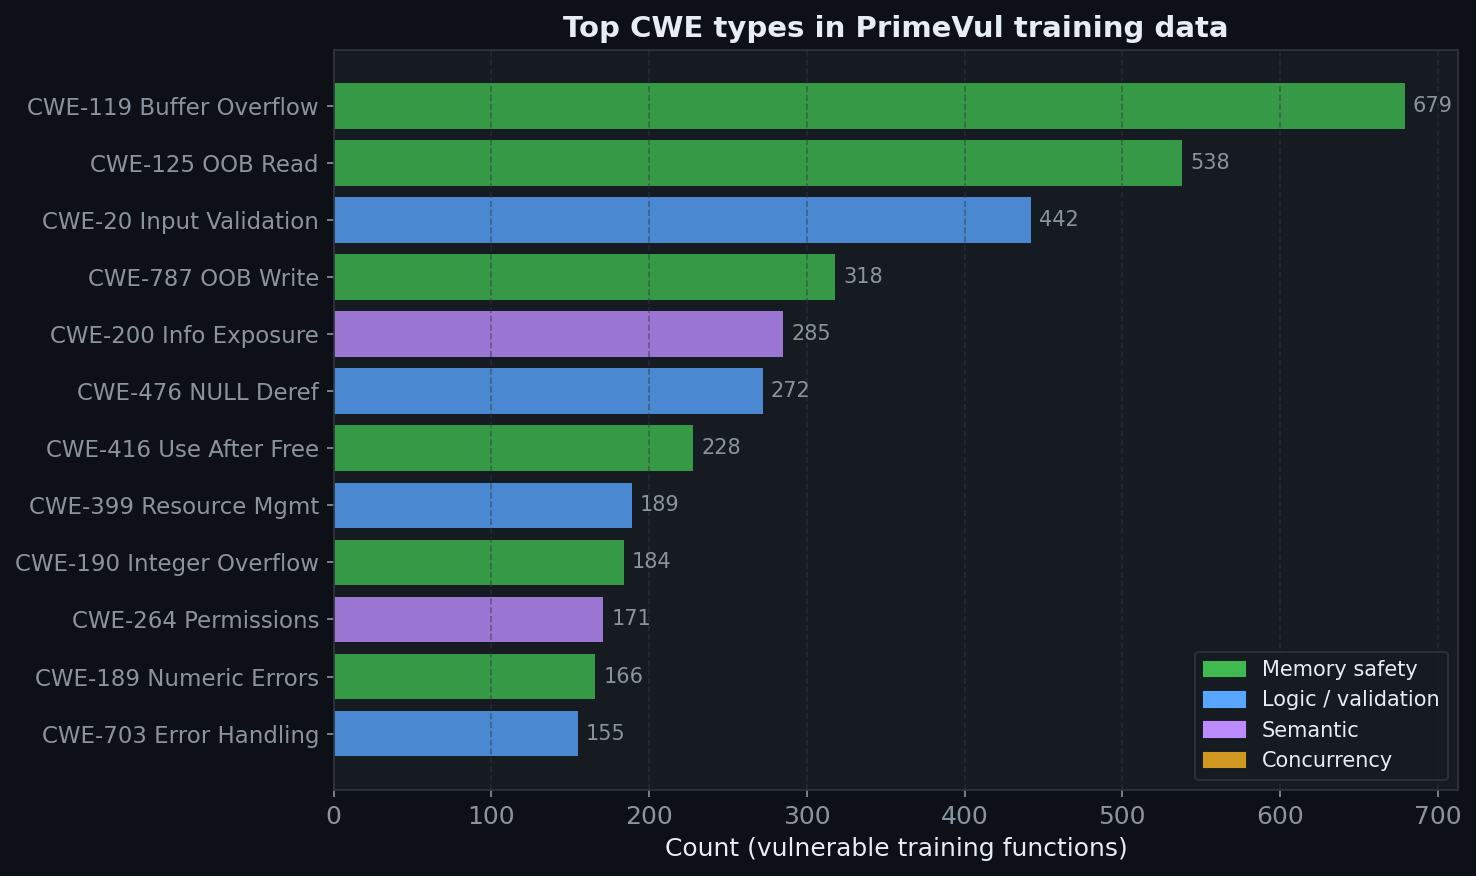


Total unique CWEs: 119


In [4]:
# Count CWEs in training vulnerable functions
cwe_counts = Counter()
for r in splits["train"]["records"]:
    if r["target"] == 1:
        for c in (r.get("cwe") or []):
            cwe_counts[c] += 1

top_cwes = cwe_counts.most_common(12)

# CWE category colors
CWE_CATEGORY = {
    "CWE-119": "mem", "CWE-125": "mem", "CWE-787": "mem", "CWE-416": "mem",
    "CWE-190": "mem", "CWE-415": "mem",
    "CWE-20": "logic", "CWE-476": "logic", "CWE-703": "logic", "CWE-617": "logic",
    "CWE-200": "semantic", "CWE-264": "semantic",
    "CWE-362": "concurrency", "CWE-399": "logic", "CWE-189": "mem",
    "CWE-401": "mem", "CWE-772": "mem",
}
CAT_COLORS = {"mem": "#3fb950", "logic": "#58a6ff", "semantic": "#bc8cff", "concurrency": "#d29922"}

CWE_NAMES = {
    "CWE-119": "Buffer Overflow", "CWE-125": "OOB Read", "CWE-20": "Input Validation",
    "CWE-787": "OOB Write", "CWE-200": "Info Exposure", "CWE-476": "NULL Deref",
    "CWE-416": "Use After Free", "CWE-399": "Resource Mgmt", "CWE-190": "Integer Overflow",
    "CWE-264": "Permissions", "CWE-189": "Numeric Errors", "CWE-703": "Error Handling",
    "CWE-362": "Race Condition", "CWE-401": "Memory Leak",
}

fig, ax = plt.subplots(figsize=(10, 6))
cwes = [c for c, _ in top_cwes]
counts = [n for _, n in top_cwes]
colors = [CAT_COLORS.get(CWE_CATEGORY.get(c, "logic"), "#8b949e") for c in cwes]
labels = [f"{c} {CWE_NAMES.get(c, '')}" for c in cwes]

bars = ax.barh(range(len(cwes)), counts, color=colors, alpha=0.8)
ax.set_yticks(range(len(cwes)))
ax.set_yticklabels(labels, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("Count (vulnerable training functions)")
ax.set_title("Top CWE types in PrimeVul training data", fontsize=14, fontweight="bold")
ax.grid(axis="x", linestyle="--")

# Value labels
for bar, count in zip(bars, counts):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(count),
            va="center", fontsize=10, color="#8b949e")

# Legend
from matplotlib.patches import Patch
legend_items = [
    Patch(color="#3fb950", label="Memory safety"),
    Patch(color="#58a6ff", label="Logic / validation"),
    Patch(color="#bc8cff", label="Semantic"),
    Patch(color="#d29922", label="Concurrency"),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig(ROOT / "figures" / "nb01_cwe_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nTotal unique CWEs: {len(cwe_counts)}")

## 4. Verify embeddings

Check that both CodeBERT and VulBERTa embeddings are valid and consistent.

In [5]:
for model_name, emb_dir in [("CodeBERT", EMB_CB), ("VulBERTa", EMB_VB)]:
    print(f"=== {model_name} ===")
    for split in ["train", "valid", "test", "test_paired"]:
        path = emb_dir / f"{split}.npz"
        if not path.exists():
            print(f"  {split}: MISSING")
            continue
        data = np.load(path, allow_pickle=False)
        embs = data["embeddings"]
        labels = data["labels"]
        l2 = np.linalg.norm(embs, axis=1).mean()
        n_nan = np.isnan(embs).sum()
        print(f"  {split:12s}: shape={embs.shape}, pos={int((labels==1).sum()):>5}, "
              f"L2={l2:.2f}, NaN={n_nan}")
    print()

# Verify labels and idxs match between models
for split in ["train", "test"]:
    cb = np.load(EMB_CB / f"{split}.npz", allow_pickle=False)
    vb = np.load(EMB_VB / f"{split}.npz", allow_pickle=False)
    labels_match = np.array_equal(cb["labels"], vb["labels"])
    idxs_match = np.array_equal(cb["idxs"], vb["idxs"])
    print(f"{split}: labels match={labels_match}, idxs match={idxs_match}")

=== CodeBERT ===


  train       : shape=(175797, 768), pos= 4862, L2=21.38, NaN=0
  valid       : shape=(23948, 768), pos=  593, L2=21.39, NaN=0


  test        : shape=(24788, 768), pos=  549, L2=21.40, NaN=0
  test_paired : shape=(870, 768), pos=  435, L2=21.61, NaN=0

=== VulBERTa ===


  train       : shape=(175797, 768), pos= 4862, L2=27.03, NaN=0
  valid       : shape=(23948, 768), pos=  593, L2=27.03, NaN=0


  test        : shape=(24788, 768), pos=  549, L2=27.03, NaN=0
  test_paired : shape=(870, 768), pos=  435, L2=27.01, NaN=0

train: labels match=True, idxs match=True
test: labels match=True, idxs match=True


## 5. PU split demonstration

Show what the PU split looks like at 20% labeling.

In [6]:
split_dir = ROOT / "data" / "processed" / "frac0.20_seed42"
with open(split_dir / "metadata.json") as f:
    meta = json.load(f)

print("PU Split at 20% labeling (seed=42):")
print(f"  P (labeled positive): {meta['n_P']:,} functions")
print(f"  U (unlabeled):        {meta['n_U']:,} functions")
print(f"  Hidden vuln in U:     {meta['n_hidden_vuln_in_U']:,} ({meta['n_hidden_vuln_in_U']/meta['n_U']:.2%} of U)")
print(f"  Class prior:          {meta['class_prior']:.4f}")

# CWE composition of P across seeds
print("\nCWE composition of P across 3 split seeds:")
for seed in [42, 123, 456]:
    sd = ROOT / "data" / "processed" / f"frac0.20_seed{seed}"
    cwes = Counter()
    with open(sd / "P.jsonl") as f:
        for line in f:
            for c in (json.loads(line).get("cwe") or []):
                cwes[c] += 1
    top3 = cwes.most_common(3)
    print(f"  seed={seed}: {', '.join(f'{c}={n}' for c, n in top3)} ...")

PU Split at 20% labeling (seed=42):
  P (labeled positive): 972 functions
  U (unlabeled):        174,825 functions
  Hidden vuln in U:     3,890 (2.23% of U)
  Class prior:          0.0277

CWE composition of P across 3 split seeds:
  seed=42: CWE-119=148, CWE-125=109, CWE-20=81 ...
  seed=123: CWE-119=143, CWE-125=118, CWE-20=86 ...
  seed=456: CWE-119=144, CWE-20=107, CWE-125=105 ...


## 6. UMAP visualizations

Side-by-side comparison of CodeBERT and VulBERTa embedding spaces. Subsample all vulnerable + 10K random benign for speed.

Fitting UMAP for CodeBERT...


/Users/dbenson/.pyenv/versions/3.12.3/envs/stat4243/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fitting UMAP for VulBERTa...


/Users/dbenson/.pyenv/versions/3.12.3/envs/stat4243/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


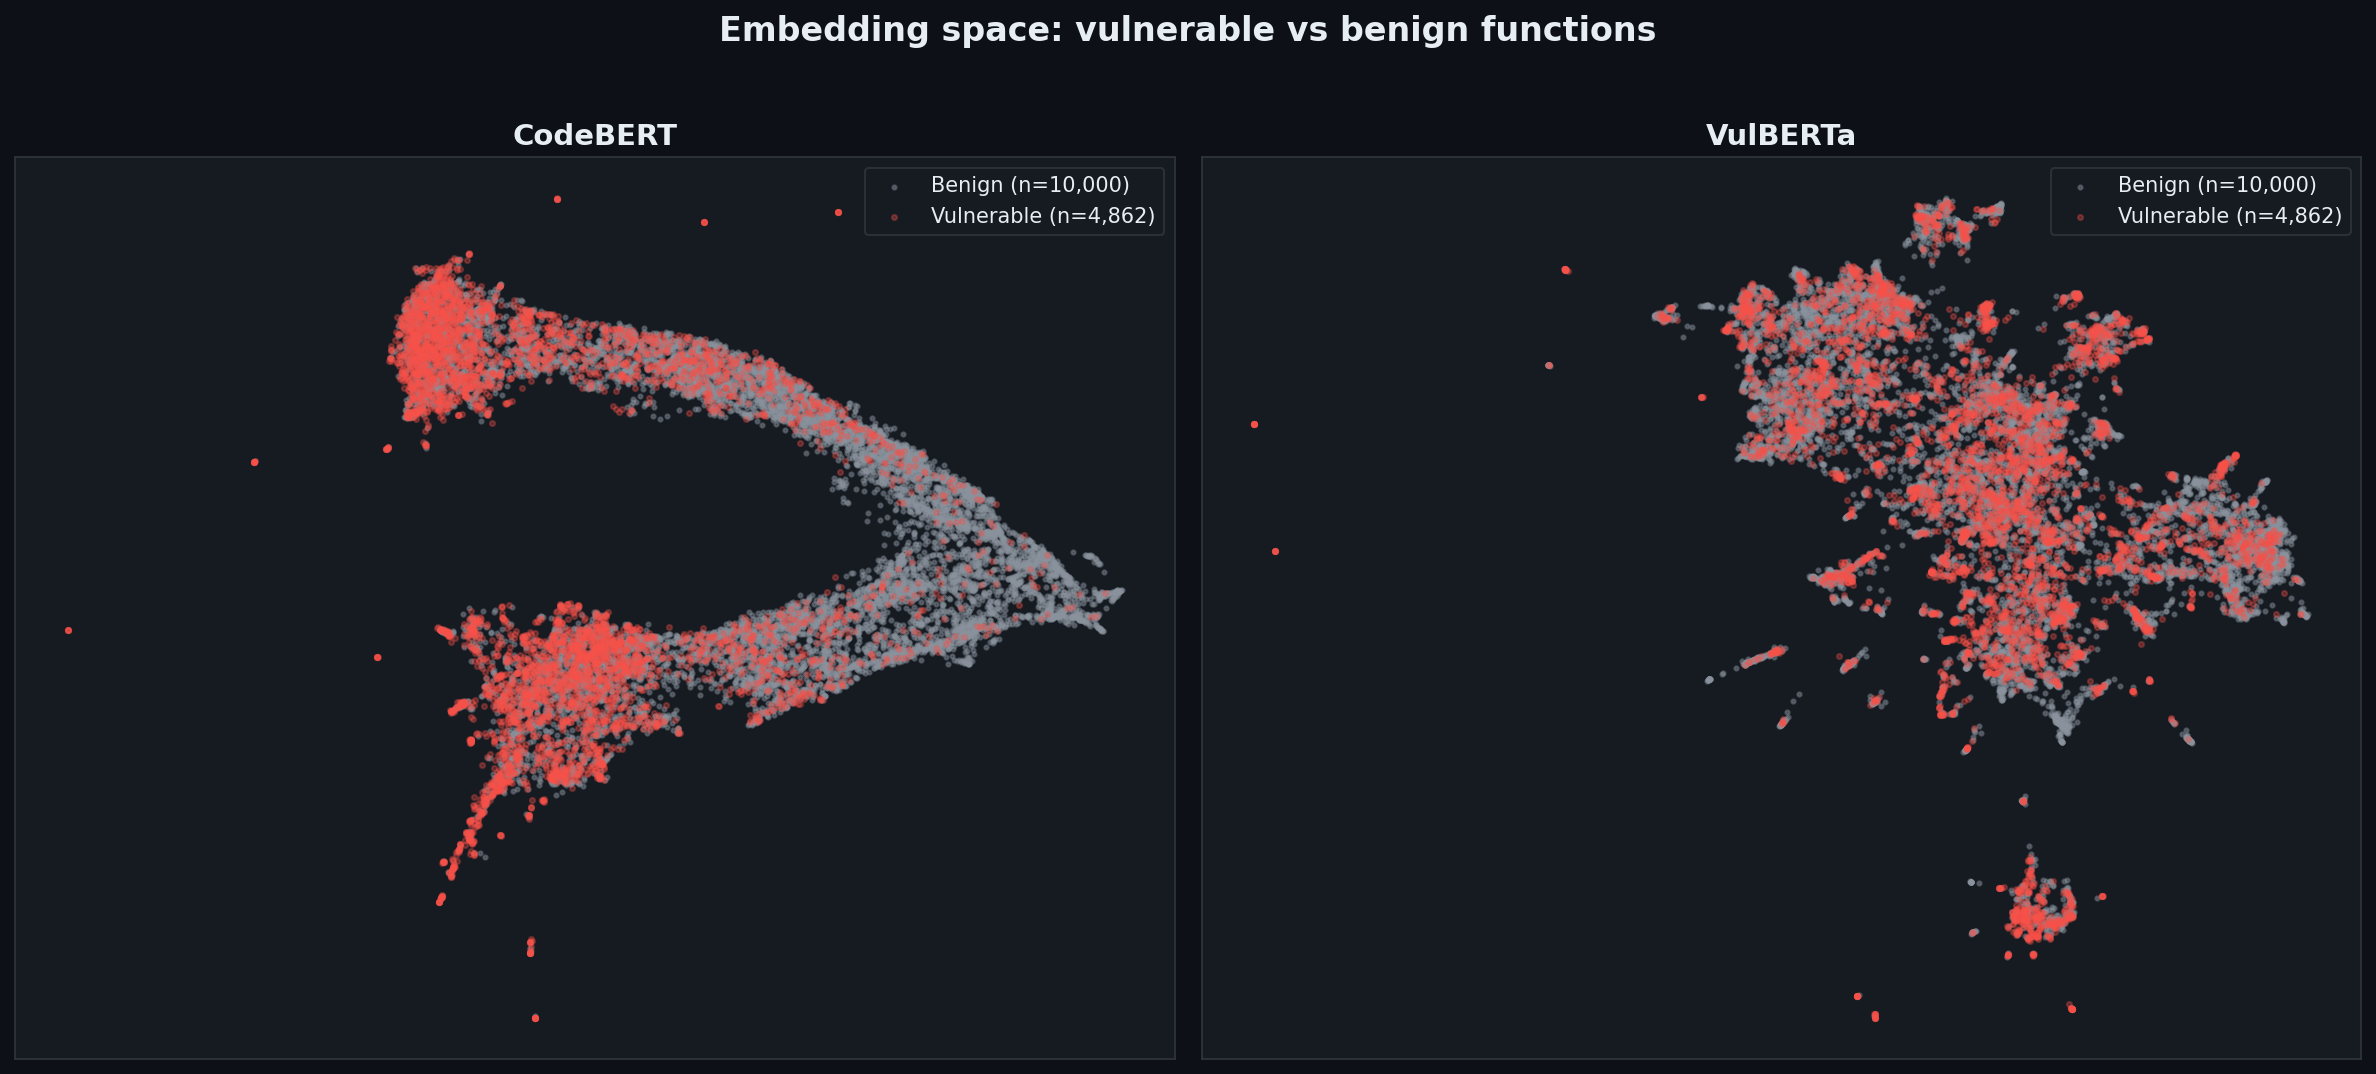


Both models show heavy overlap between vulnerable and benign functions.
The frozen [CLS] embeddings do not cleanly separate the two classes.


In [7]:
import umap
import warnings
warnings.filterwarnings("ignore", message=".*spectral.*")

def compute_umap(emb_dir, seed=42):
    data = np.load(emb_dir / "train.npz", allow_pickle=False)
    X, y = data["embeddings"], data["labels"]
    
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]
    rng = np.random.RandomState(seed)
    neg_sample = rng.choice(neg_idx, size=10000, replace=False)
    idx = np.concatenate([neg_sample, pos_idx])
    rng.shuffle(idx)
    
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=seed)
    embedding = reducer.fit_transform(X[idx])
    return embedding, y[idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (name, emb_dir) in zip(axes, [("CodeBERT", EMB_CB), ("VulBERTa", EMB_VB)]):
    print(f"Fitting UMAP for {name}...")
    emb_2d, labels = compute_umap(emb_dir)
    
    neg_mask = labels == 0
    pos_mask = labels == 1
    
    ax.scatter(emb_2d[neg_mask, 0], emb_2d[neg_mask, 1],
               c="#8b949e", s=4, alpha=0.4, label=f"Benign (n={neg_mask.sum():,})", rasterized=True)
    ax.scatter(emb_2d[pos_mask, 0], emb_2d[pos_mask, 1],
               c="#f85149", s=6, alpha=0.3, label=f"Vulnerable (n={pos_mask.sum():,})", rasterized=True)
    
    ax.set_title(name, fontsize=14, fontweight="bold")
    ax.legend(loc="upper right", fontsize=10, framealpha=0.8)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("Embedding space: vulnerable vs benign functions", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "figures" / "nb01_umap_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nBoth models show heavy overlap between vulnerable and benign functions.")
print("The frozen [CLS] embeddings do not cleanly separate the two classes.")

## 7. Embedding magnitude distribution

Compare the L2 norm distributions of CodeBERT vs VulBERTa, and vulnerable vs benign.

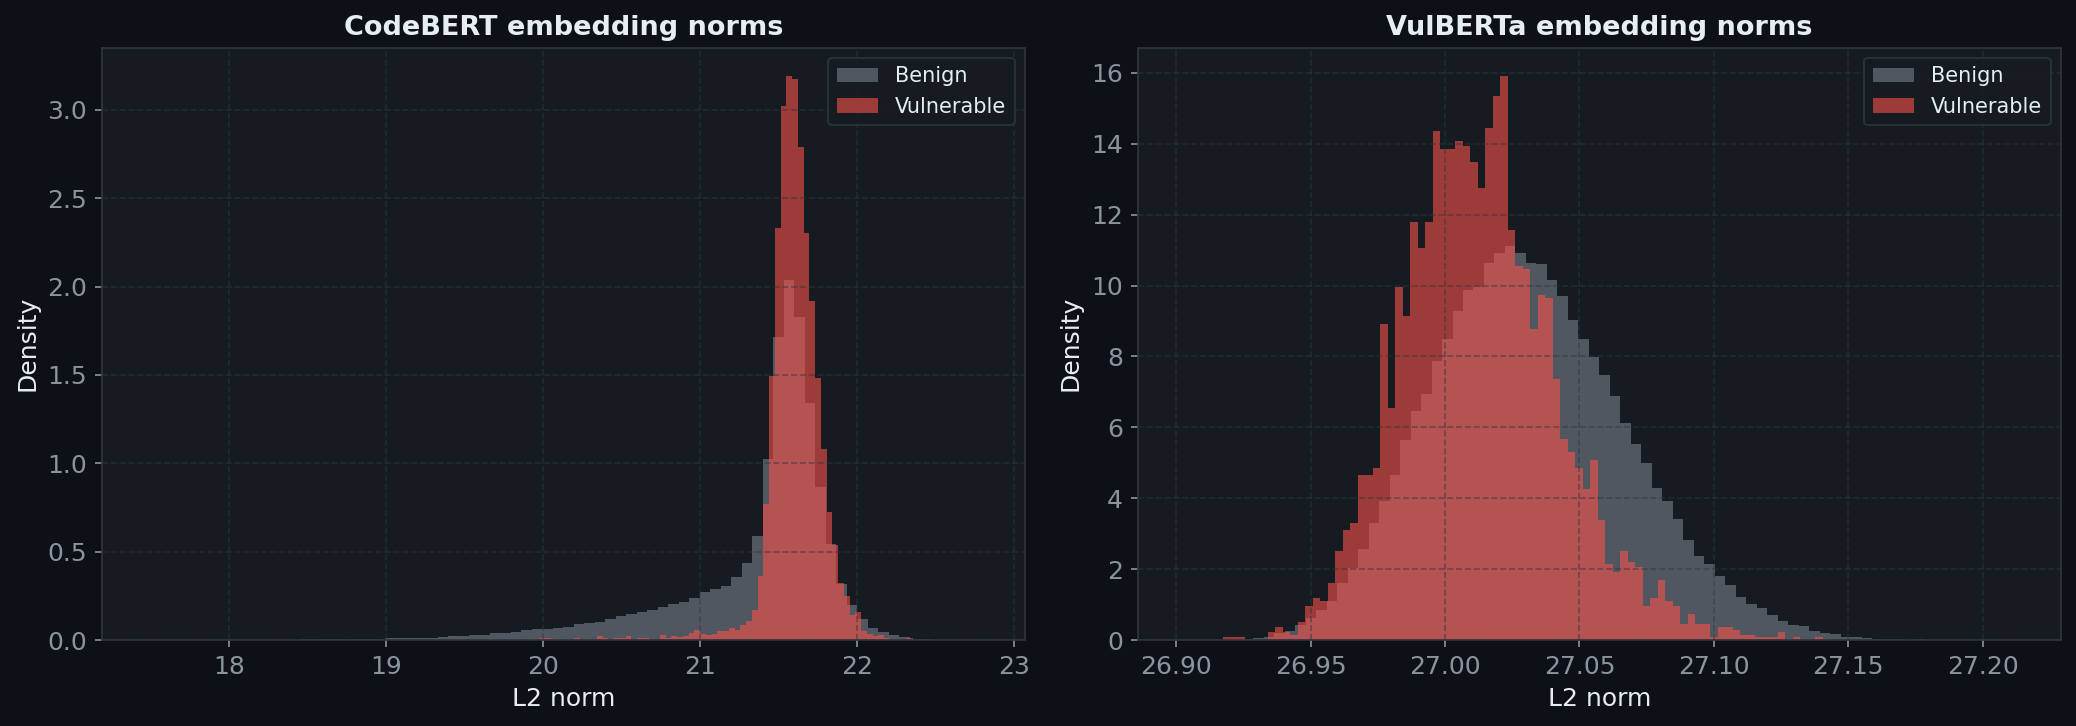

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, emb_dir, color) in zip(axes, [
    ("CodeBERT", EMB_CB, "#58a6ff"), ("VulBERTa", EMB_VB, "#bc8cff")
]):
    data = np.load(emb_dir / "train.npz", allow_pickle=False)
    X, y = data["embeddings"], data["labels"]
    norms = np.linalg.norm(X, axis=1)
    
    ax.hist(norms[y == 0], bins=80, alpha=0.5, color="#8b949e", label="Benign", density=True)
    ax.hist(norms[y == 1], bins=80, alpha=0.6, color="#f85149", label="Vulnerable", density=True)
    ax.set_xlabel("L2 norm")
    ax.set_ylabel("Density")
    ax.set_title(f"{name} embedding norms", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--")

plt.tight_layout()
plt.savefig(ROOT / "figures" / "nb01_embedding_norms.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary

- PrimeVul v0.1: 175K train / 24K valid / 25K test, 2.77% class prior
- 100+ CWE types, dominated by memory safety bugs (CWE-119, CWE-125, CWE-787)
- CodeBERT and VulBERTa embeddings both produce 768-d vectors, labels and idxs match exactly
- VulBERTa has higher L2 magnitude (~27 vs ~21) but same dimensionality
- UMAP shows heavy overlap between vulnerable and benign for both models
- PU split at 20% labeling: P=972 confirmed, U=174,825 with 3,890 hidden vulnerabilities
- CWE composition of P is stable across seeds at 20% (SCAR holds)

**Next: Notebook 02 (baseline comparison)**